# Chess Game Outcome Prediction
### Intro to Machine Learning | Final Project

**Dataset:** [Chess Game Dataset (Lichess)](https://www.kaggle.com/datasets/datasnaek/chess)
**Task:** Multiclass Classification — Predict the winner of a chess game (`white`, `black`, or `draw`)
**Dataset size:** ~20,000 games, 16 features

---
# Setup & Imports

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import KBinsDiscretizer
from itertools import product

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')


---
# Load Dataset

In [78]:
DATA_PATH = 'data/games.csv'

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("Columns:", list(df.columns))
df.head()

Shape: (20058, 16)
Columns: ['id', 'rated', 'created_at', 'last_move_at', 'turns', 'victory_status', 'winner', 'increment_code', 'white_id', 'white_rating', 'black_id', 'black_rating', 'moves', 'opening_eco', 'opening_name', 'opening_ply']


,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,moves,opening_eco,opening_name,opening_ply
0,TZJHLljE,False,1.504210e+12,1.504210e+12,13,outoftime,white,15+2,bourgris,1500,a-00,1191,d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5...,D10,Slav Defense: Exchange Variation,5
1,l1NXvwaE,True,1.504130e+12,1.504130e+12,16,resign,black,5+10,a-00,1322,skinnerua,1261,d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6...,B00,Nimzowitsch Defense: Kennedy Variation,4
2,mIICvQHh,True,1.504130e+12,1.504130e+12,61,mate,white,5+10,ischia,1496,a-00,1500,e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc...,C20,King's Pawn Game: Leonardis Variation,3
3,kWKvrqYL,True,1.504110e+12,1.504110e+12,61,mate,white,20+0,daniamurashov,1439,adivanov2009,1454,d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 O...,D02,Queen's Pawn Game: Zukertort Variation,3
4,9tXo1AUZ,True,1.504030e+12,1.504030e+12,95,mate,white,30+3,nik221107,1523,adivanov2009,1469,e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 N...,C41,Philidor Defense,5


---
# Initial Exploration

In [79]:
print("=== Data Types & Non-Null Counts ===")
df.info()

print("\n=== Summary Statistics (numeric) ===")
df.describe()

=== Data Types & Non-Null Counts ===
<class 'pandas.DataFrame'>
RangeIndex: 20058 entries, 0 to 20057
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              20058 non-null  str    
 1   rated           20058 non-null  bool   
 2   created_at      20058 non-null  float64
 3   last_move_at    20058 non-null  float64
 4   turns           20058 non-null  int64  
 5   victory_status  20058 non-null  str    
 6   winner          20058 non-null  str    
 7   increment_code  20058 non-null  str    
 8   white_id        20058 non-null  str    
 9   white_rating    20058 non-null  int64  
 10  black_id        20058 non-null  str    
 11  black_rating    20058 non-null  int64  
 12  moves           20058 non-null  str    
 13  opening_eco     20058 non-null  str    
 14  opening_name    20058 non-null  str    
 15  opening_ply     20058 non-null  int64  
dtypes: bool(1), float64(2), int64(4), str(9)
memory us

,created_at,last_move_at,turns,white_rating,black_rating,opening_ply
count,2.005800e+04,2.005800e+04,20058.000000,20058.000000,20058.000000,20058.000000
mean,1.483617e+12,1.483618e+12,60.465999,1596.631868,1588.831987,4.816981
std,2.850151e+10,2.850140e+10,33.570585,291.253376,291.036126,2.797152
min,1.376772e+12,1.376772e+12,1.000000,784.000000,789.000000,1.000000
25%,1.477548e+12,1.477548e+12,37.000000,1398.000000,1391.000000,3.000000
50%,1.496010e+12,1.496010e+12,55.000000,1567.000000,1562.000000,4.000000
75%,1.503170e+12,1.503170e+12,79.000000,1793.000000,1784.000000,6.000000
max,1.504493e+12,1.504494e+12,349.000000,2700.000000,2723.000000,28.000000


In [80]:
print("=== Missing Values ===")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else "No missing values.")

=== Missing Values ===
No missing values.


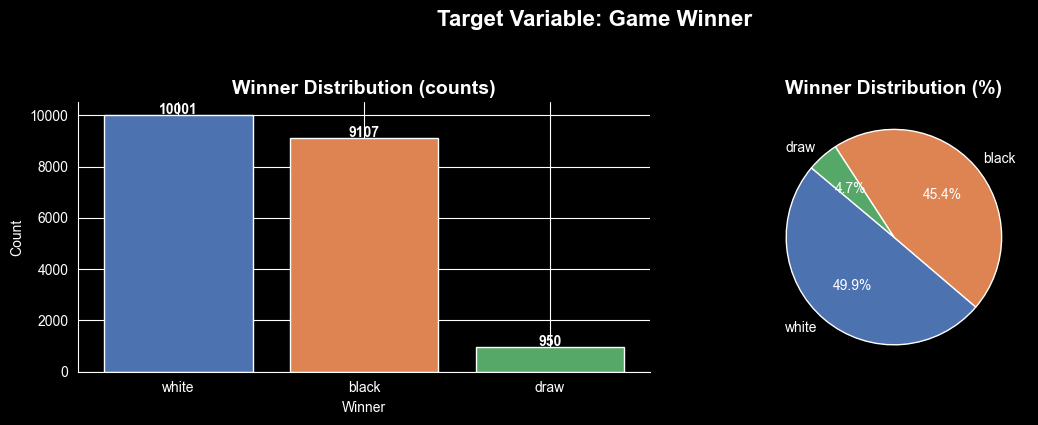

winner
white    10001
black     9107
draw       950
Name: count, dtype: int64


In [81]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

winner_counts = df['winner'].value_counts()
axes[0].bar(winner_counts.index, winner_counts.values, color=['#4C72B0', '#DD8452', '#55A868'])
axes[0].set_title("Winner Distribution (counts)", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Winner")
axes[0].set_ylabel("Count")
for i, (label, val) in enumerate(winner_counts.items()):
    axes[0].text(i, val + 50, str(val), ha='center', fontweight='bold')

axes[1].pie(winner_counts.values, labels=winner_counts.index, autopct='%1.1f%%', startangle=140, colors=['#4C72B0', '#DD8452', '#55A868'])
axes[1].set_title("Winner Distribution (%)", fontsize=14, fontweight='bold')

plt.suptitle("Target Variable: Game Winner", fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('figures/fig_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(winner_counts)

---
# Feature Engineering & Preprocessing

In [82]:
df_model = df.copy()

# Rating difference (white perspective) ─────────────────────────────────
# Positive indicates white is stronger; negative indicates black is stronger
df_model['rating_diff'] = df_model['white_rating'] - df_model['black_rating']

# Average rating of game ─────────────────────────────────
df_model['avg_rating'] = (df_model['white_rating'] + df_model['black_rating']) / 2

# Encode 'rated' column (binary)  ─────────────────────────────────
df_model['is_rated'] = df_model['rated'].astype(int)

# Parse time control: extract base seconds from increment code  ─────────────────────────────────
def parse_time_control(tc):
    try:
        parts = str(tc).split('+')
        return int(parts[0])
    except:
        return np.nan

df_model['time_base_minutes'] = df_model['increment_code'].apply(parse_time_control)

# Extract time increment  ─────────────────────────────────
def parse_increment(tc):
    try:
        parts = str(tc).split('+')
        return int(parts[1])
    except:
        return 0

df_model['time_increment'] = df_model['increment_code'].apply(parse_increment)

# Label encode game end status (mate, out of time, resign, draw)
le_victory = LabelEncoder()
df_model['victory_status_enc'] = le_victory.fit_transform(df_model['victory_status'].astype(str))
print("Victory status classes:", le_victory.classes_)

print("\nEngineered features preview:")
df_model[['rating_diff', 'avg_rating', 'is_rated', 'time_base_minutes', 'time_increment', 'victory_status_enc']].head()

Victory status classes: ['draw' 'mate' 'outoftime' 'resign']

Engineered features preview:


,rating_diff,avg_rating,is_rated,time_base_minutes,time_increment,victory_status_enc
0,309,1345.5,0,15,2,2
1,61,1291.5,1,5,10,3
2,-4,1498.0,1,5,10,1
3,-15,1446.5,1,20,0,1
4,54,1496.0,1,30,3,1


In [83]:
FEATURES = [
    'rating_diff',
    'avg_rating',
    'is_rated',
    'white_rating',
    'black_rating',
    'turns',
    'opening_ply',
    'time_base_minutes',
    'time_increment',
    'victory_status_enc'
]

TARGET = 'winner'

# Encode target
le_target = LabelEncoder()
df_model['winner_enc'] = le_target.fit_transform(df_model[TARGET])
print("Target classes:", le_target.classes_)
df_model['winner_enc'].head()

X = df_model[FEATURES].copy()
y = df_model['winner_enc'].copy()

# Drop any rows with NaN (from possible time control parsing failures)
nofail = X.notna().all(axis=1)
X, y = X[nofail], y[nofail]

print("\nFinal dataset:", X.shape[0], "samples,", X.shape[1], "features")
print(f"Class distribution:\n{pd.Series(le_target.inverse_transform(y)).value_counts()}")

Target classes: ['black' 'draw' 'white']

Final dataset: 20058 samples, 10 features
Class distribution:
white    10001
black     9107
draw       950
Name: count, dtype: int64


In [84]:
# Train / Val / Test split: 70 / 15 / 15
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp)

print(f"Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}")

# Scale features  ─────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete")

Train: 14040 | Val: 3009 | Test: 3009
Scaling complete


---
# Exploratory Data Analysis

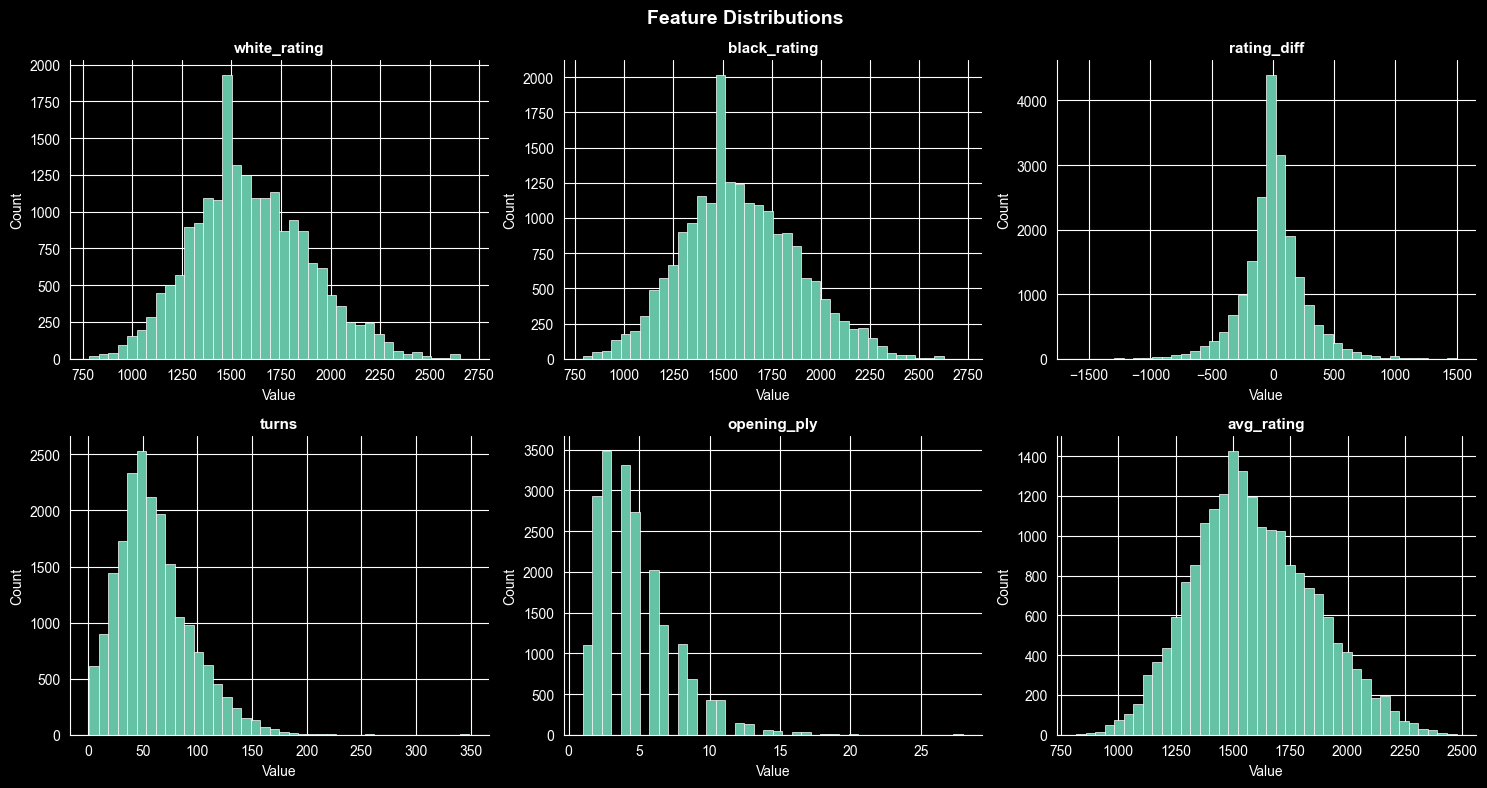

In [85]:
# Numeric feature distributions
numeric_features = ['white_rating', 'black_rating', 'rating_diff', 'turns', 'opening_ply', 'avg_rating']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(numeric_features):
    axes[i].hist(df_model[feat], bins=40, edgecolor='white', linewidth=0.5)
    axes[i].set_title(feat, fontsize=11, fontweight='bold')
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Count")

plt.suptitle("Feature Distributions", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("figures/fig_feature_distributions.png", dpi=150, bbox_inches='tight')
plt.show()

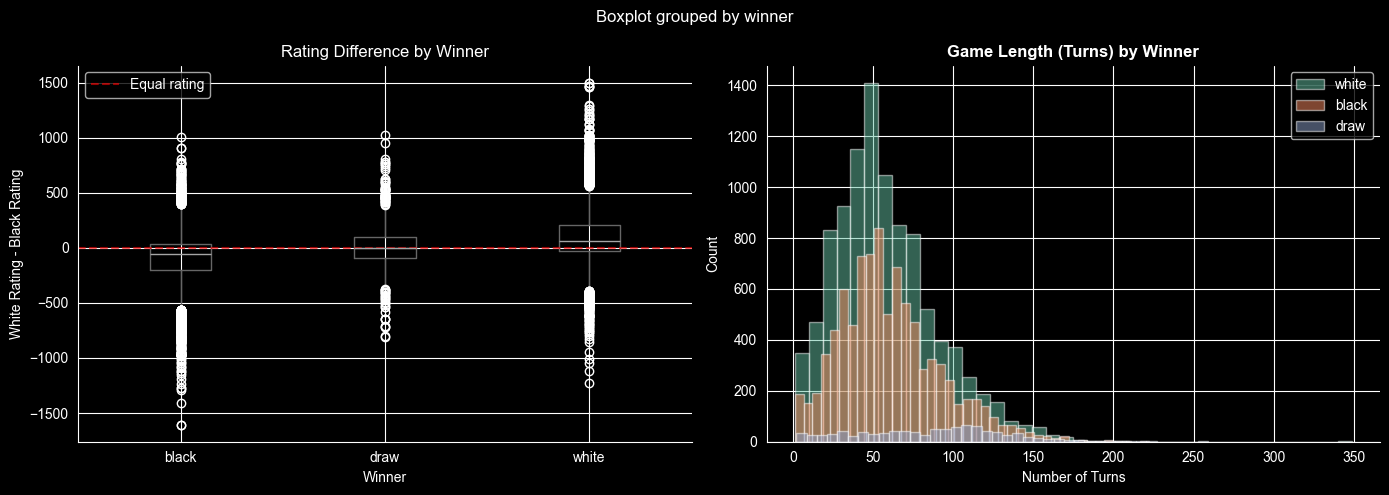

In [86]:
# Rating diff vs. winner
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_model.boxplot(column='rating_diff', by='winner', ax=axes[0])
axes[0].set_title("Rating Difference by Winner", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Winner")
axes[0].set_ylabel("White Rating - Black Rating")
axes[0].axhline(0, color='red', linestyle='--', alpha=0.6, label='Equal rating')
axes[0].legend()
plt.sca(axes[0])
plt.title('Rating Difference by Winner')

for label in df_model['winner'].unique():
    subset = df_model[df_model['winner'] == label]['turns']
    axes[1].hist(subset, bins=40, alpha=0.5, label=label, edgecolor='white')

axes[1].set_title("Game Length (Turns) by Winner", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Number of Turns")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.savefig("figures/fig_rating_diff_turns.png", dpi=150, bbox_inches='tight')
plt.show()

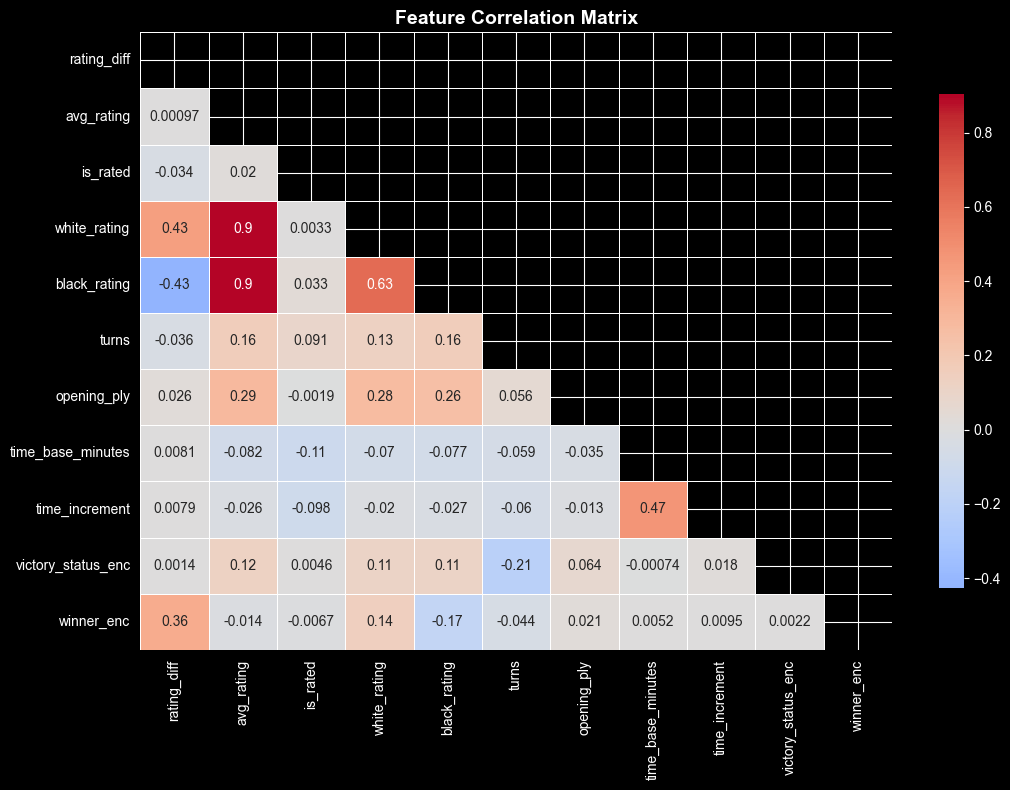

In [87]:
# Correlation matrix
corr_df = df_model[FEATURES + ['winner_enc']].corr()

plt.figure(figsize=(11, 8))
mask = np.triu(np.ones_like(corr_df, dtype=bool))
sns.heatmap(corr_df, mask=mask, annot=True, cmap='coolwarm', center=0, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Feature Correlation Matrix", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("figures/fig_correlation_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

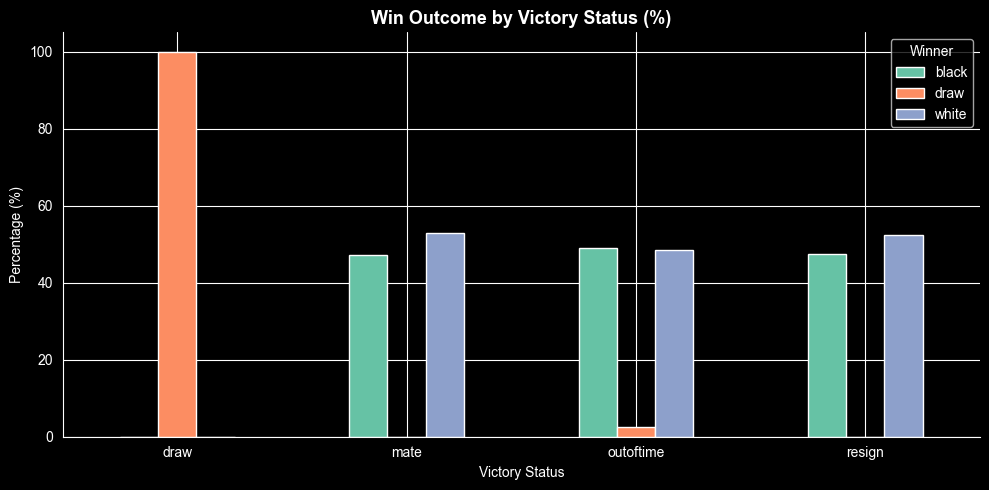

In [88]:
# Victory status breakdown
fig, ax = plt.subplots(figsize=(10, 5))
ct = pd.crosstab(df_model['victory_status'], df_model['winner'], normalize='index') * 100
ct.plot(kind='bar', ax=ax, edgecolor='white')
ax.set_title("Win Outcome by Victory Status (%)", fontsize=13, fontweight='bold')
ax.set_xlabel("Victory Status")
ax.set_ylabel("Percentage (%)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Winner')
plt.tight_layout()
plt.savefig("figures/fig_victory_status.png", dpi=150, bbox_inches='tight')
plt.show()

---
# Baseline Models

In [89]:
def evaluate_model(model, X_train, y_train, X_val, y_val, name=''):
    model.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, model.predict(X_train))
    val_acc = accuracy_score(y_val, model.predict(X_val))

    y_val_pred = model.predict(X_val)
    precision = precision_score(y_val, y_val_pred, average='weighted', zero_division=0)
    recall = recall_score(y_val, y_val_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_val, y_val_pred, average='weighted', zero_division=0)

    print(f"\n── {name}  ─────────────────────────────────")
    print(f"  Train Accuracy : {train_acc:.4f}")
    print(f"  Val   Accuracy : {val_acc:.4f}")
    print(f"  Val   Precision: {precision:.4f}")
    print(f"  Val   Recall   : {recall:.4f}")
    print(f"  Val   F1       : {f1:.4f}")

    return {
        "Model": name,
        "Train Accuracy": round(train_acc, 4),
        "Val Accuracy": round(val_acc, 4),
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1": round(f1, 4)
    }

results = []

In [90]:
# 1. Logistic Regression
lr_baseline = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
results.append(evaluate_model(lr_baseline, X_train_scaled, y_train, X_val_scaled, y_val, name='Logistic Regression (baseline)'))


── Logistic Regression (baseline)  ─────────────────────────────────
  Train Accuracy : 0.6713
  Val   Accuracy : 0.6723
  Val   Precision: 0.6728
  Val   Recall   : 0.6723
  Val   F1       : 0.6714


In [91]:
# 2. K-Nearest Neighbors
knn_baseline = KNeighborsClassifier(n_neighbors=5)
results.append(evaluate_model(knn_baseline, X_train_scaled, y_train, X_val_scaled, y_val, 'KNN (k=5, baseline)'))


── KNN (k=5, baseline)  ─────────────────────────────────
  Train Accuracy : 0.7600
  Val   Accuracy : 0.6211
  Val   Precision: 0.6229
  Val   Recall   : 0.6211
  Val   F1       : 0.6214


In [92]:
# 3. Support Vector Machine
svm_baseline = SVC(kernel='rbf', C=1.0, random_state=RANDOM_STATE)
results.append(evaluate_model(svm_baseline, X_train_scaled, y_train, X_val_scaled, y_val, 'SVM (RBF, C=1, baseline)'))


── SVM (RBF, C=1, baseline)  ─────────────────────────────────
  Train Accuracy : 0.6880
  Val   Accuracy : 0.6717
  Val   Precision: 0.6734
  Val   Recall   : 0.6717
  Val   F1       : 0.6691


In [93]:
# Summary
results_df = pd.DataFrame(results)
results_df

,Model,Train Accuracy,Val Accuracy,Precision,Recall,F1
0,Logistic Regression (baseline),0.6713,0.6723,0.6728,0.6723,0.6714
1,"KNN (k=5, baseline)",0.7600,0.6211,0.6229,0.6211,0.6214
2,"SVM (RBF, C=1, baseline)",0.6880,0.6717,0.6734,0.6717,0.6691


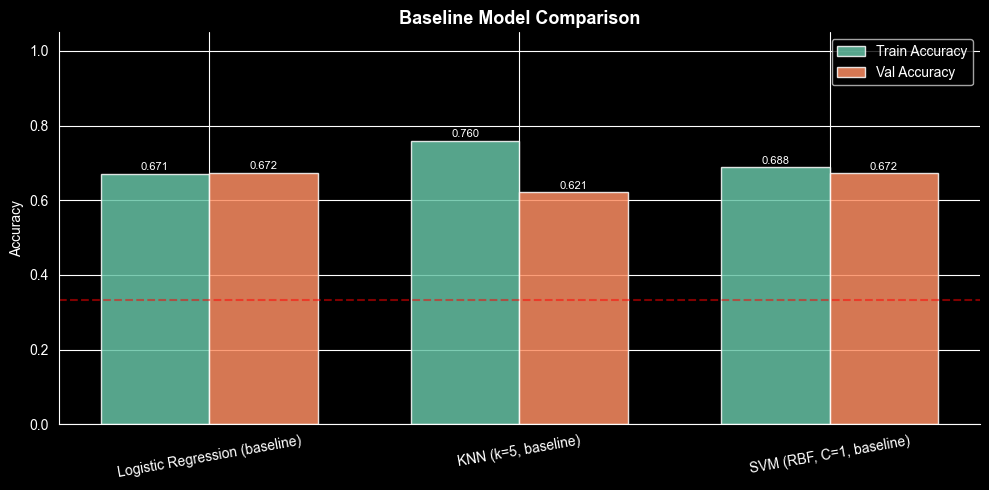

In [94]:
# Bar chart comparison
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(results_df))
width = 0.35

bars1 = ax.bar(x - width/2, results_df['Train Accuracy'], width, label='Train Accuracy', alpha=0.85)
bars2 = ax.bar(x + width/2, results_df['Val Accuracy'], width, label='Val Accuracy', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=10, ha='center')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.05)
ax.set_title('Baseline Model Comparison', fontsize=13, fontweight='bold')
ax.legend()
ax.axhline(y=1/3, color='red', linestyle='--', alpha=0.5, label='Random chance (33%)')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f"{bar.get_height():.3f}", ha='center', va='bottom', fontsize=8)

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f"{bar.get_height():.3f}", ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig("figures/fig_baseline_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

Best baseline: Logistic Regression (baseline)


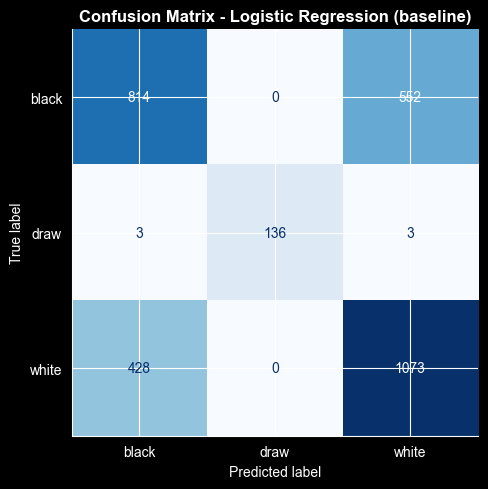


Classification Report:
              precision    recall  f1-score   support

       black       0.65      0.60      0.62      1366
        draw       1.00      0.96      0.98       142
       white       0.66      0.71      0.69      1501

    accuracy                           0.67      3009
   macro avg       0.77      0.76      0.76      3009
weighted avg       0.67      0.67      0.67      3009



In [95]:
# Confusion matrix for best baseline

# Use the best val-accuracy model
best_idx = results_df['Val Accuracy'].idxmax()
best_name = results_df.loc[best_idx, 'Model']
print(f"Best baseline: {best_name}")

# Reuse whichever fitted model was best
model_map = {
    results_df.loc[0, 'Model']: lr_baseline,
    results_df.loc[1, 'Model']: knn_baseline,
    results_df.loc[2, 'Model']: svm_baseline,
}
best_model = model_map[best_name]

y_pred_best = best_model.predict(X_val_scaled)
cm = confusion_matrix(y_val, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_target.classes_)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f"Confusion Matrix - {best_name}", fontweight='bold')
plt.tight_layout()
plt.savefig("figures/fig_confusion_matrix_best.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nClassification Report:")
print(classification_report(y_val, y_pred_best, target_names=le_target.classes_))

---
# Feature Transformations

We apply three distinct feature transformations to map the data into new feature spaces (Z-spaces). Each transformation is applied to the already-split and scaled data where appropriate.

- **T0:** Untransformed (scaled baseline features — already done above)
- **T1:** Polynomial Features (degree=2) on rating/turns features
- **T2:** Log Transform on skewed features
- **T3:** Opening ECO family one-hot encoding added to feature set

In [96]:
# T1: Polynomial Features (degree=2)─────────────────────────────────────
# Captures interaction terms and squared effects among rating/game features.
# ex: rating_diff^2, rating diff x turns — nonlinear relationships that a linear model like LogisticRegression cannot capture in the original space.

poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = poly.fit_transform(X_train_scaled) # fit on train only
X_val_poly = poly.transform(X_val_scaled)
X_test_poly = poly.transform(X_test_scaled)

print(f"T1 Polynomial: {X_train_scaled.shape[1]} -> {X_train_poly.shape[1]} features")

T1 Polynomial: 10 -> 65 features


In [97]:
# ── T2: Log Transform on skewed features ─────────────────────────────────────
# turns, time_base_minutes, and opening_ply are all right-skewed.
# Log-compressing them pulls in extreme values and makes the
# distribution more symmetric, which helps distance-based models (KNN) and improves LR's linear decision boundaries.

LOG_FEATURES = ['turns', 'time_base_minutes', 'opening_ply']
LOG_INDICIES = [FEATURES.index(f) for f in LOG_FEATURES]

def apply_log_transform(X_scaled, X_raw, log_indicies):
    """Replace log-target columns with log1p of their raw (pre-scale) values,
    then re-scale the whole matrix so all features stay on the same scale."""
    X_log = X_raw.astype(float).copy()
    for idx in log_indicies:
        X_log.iloc[:, idx] = np.log1p(X_log.iloc[:, idx].abs())
    return X_log

X_train_log_raw = apply_log_transform(X_train_scaled, X_train, LOG_INDICIES)
X_val_log_raw = apply_log_transform(X_val_scaled, X_val, LOG_INDICIES)
X_test_log_raw = apply_log_transform(X_test_scaled, X_test, LOG_INDICIES)

# Rescale after log transform
scaler_log = StandardScaler()
X_train_log = scaler_log.fit_transform(X_train_log_raw)
X_val_log = scaler_log.transform(X_val_log_raw)
X_test_log = scaler_log.transform(X_test_log_raw)

print(f"T2 Log Transform: {X_train_log.shape[1]} features (same count, skew reduced)")

T2 Log Transform: 10 features (same count, skew reduced)


In [98]:
# ── T3: Opening ECO Family Encoding ──────────────────────────────────────────
# ECO codes follow the format A00–E99. The first letter groups openings
# into 5 families (A=flank, B=semi-open, C=open, D=closed, E=Indian).
# One-hot encoding the family letter (5 columns) adds real chess-domain signal without the cardinality explosion of encoding all 500 ECO codes.

df_model['eco_family'] = df_model['opening_eco'].astype(str).str[0].str.upper()
df_model['eco_family'] = df_model['eco_family'].where(
    df_model['eco_family'].isin(['A', 'B', 'C', 'D', 'E']), other='A'
)

eco_dummies = pd.get_dummies(df_model['eco_family'], prefix='eco')
eco_dummies.index = df_model.index

# Filter to same rows as X (after NaN drop)
eco_dummies = eco_dummies.loc[X.index]

# Align train/val/test indicies
eco_train = eco_dummies.loc[X_train.index].values.astype(float)
eco_val = eco_dummies.loc[X_val.index].values.astype(float)
eco_test = eco_dummies.loc[X_test.index].values.astype(float)

# Append ECO columns to the scaled baseline features
X_train_eco = np.hstack([X_train_scaled, eco_train])
X_val_eco = np.hstack([X_val_scaled, eco_val])
X_test_eco = np.hstack([X_test_scaled, eco_test])

print(f"T3 ECO Encoding: {X_train_scaled.shape[1]} -> {X_train_eco.shape[1]} features")
print(f"ECO family distribution:\n{df_model['eco_family'].value_counts()}")

T3 ECO Encoding: 10 -> 15 features
ECO family distribution:
eco_family
C    7658
B    5238
A    3973
D    2683
E     506
Name: count, dtype: int64


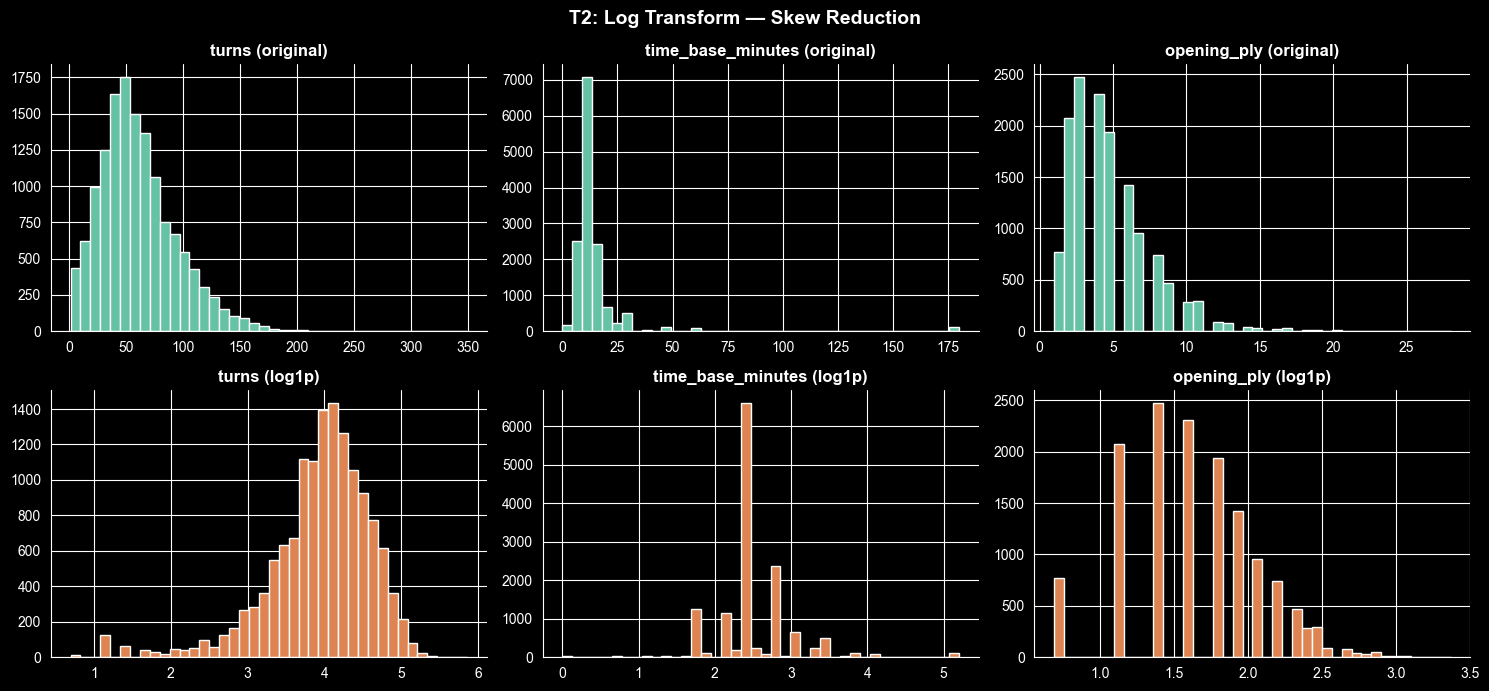

In [99]:
# Visualizing the skew reduction from T2
fig, axes = plt.subplots(2, 3, figsize=(15, 7))

for i, feat in enumerate(LOG_FEATURES):
    col_idx = FEATURES.index(feat)
    axes[0, i].hist(X_train.iloc[:, col_idx], bins=40, edgecolor='white')
    axes[0, i].set_title(f"{feat} (original)", fontweight='bold')
    axes[1, i].hist(X_train_log_raw.iloc[:, col_idx], bins=40, edgecolor='white', color='#DD8452')
    axes[1, i].set_title(f"{feat} (log1p)", fontweight='bold')

plt.suptitle("T2: Log Transform — Skew Reduction", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("figures/fig_log_transform.png", dpi=150, bbox_inches='tight')
plt.show()

---
# Regularization Sweeps

Each of the three models is trained across:
- 4 feature spaces: T0 (baseline), T1 (poly), T2 (log), T3 (eco)
- 6 hyperparameter values per model

Total: 3 models × 4 spaces × 6 values = **72 models**

In [100]:
# ── Helper: evaluate one fitted model ────────────────────────────────────────
def score_model(model, X_tr, y_tr, X_v, y_v):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_v)
    return {
        'Train Acc': round(accuracy_score(y_tr, model.predict(X_tr)), 4),
        'Val Acc':    round(accuracy_score(y_v, y_pred), 4),
        'Precision':  round(precision_score(y_v, y_pred, average='weighted', zero_division=0), 4),
        'Recall':     round(recall_score(y_v, y_pred, average='weighted', zero_division=0), 4),
        'F1':         round(f1_score(y_v, y_pred, average='weighted', zero_division=0), 4),
    }

# Feature spaces dict
spaces = {
    'T0 (baseline)': (X_train_scaled, X_val_scaled, X_test_scaled),
    'T1 (poly)':     (X_train_poly,   X_val_poly,   X_test_poly),
    'T2 (log)':      (X_train_log,    X_val_log,    X_test_log),
    'T3 (eco)':      (X_train_eco,    X_val_eco,    X_test_eco),
}

all_results = []  # will accumulate all 72+ rows
print("Feature spaces ready.")

Feature spaces ready.


In [101]:
# ── Logistic Regression sweep: C ─────────────────────────────────────────────
# C is the inverse of regularization strength.
# Small C → strong regularization (high bias), Large C → weak regularization (high variance).

C_values = [0.001, 0.01, 0.1, 1, 10, 100]
lr_results = []

for space_name, (Xtr, Xv, Xte) in spaces.items():
    for C in C_values:
        model = LogisticRegression(C=C, max_iter=1000,
                                   class_weight='balanced',
                                   random_state=RANDOM_STATE)
        scores = score_model(model, Xtr, y_train, Xv, y_val)
        row = {'Model': 'Logistic Regression', 'Space': space_name,
               'Hyperparam': f'C={C}', **scores}
        lr_results.append(row)
        all_results.append(row)

lr_df = pd.DataFrame(lr_results)
print("Logistic Regression sweep complete.")
print(f"{len(lr_df)} models trained ({len(spaces)} spaces × {len(C_values)} C values)")
lr_df

Logistic Regression sweep complete.
24 models trained (4 spaces × 6 C values)


,Model,Space,Hyperparam,Train Acc,Val Acc,Precision,Recall,F1
0,Logistic Regression,T0 (baseline),C=0.001,0.6137,0.6188,0.6487,0.6188,0.6251
1,Logistic Regression,T0 (baseline),C=0.01,0.6562,0.6550,0.6561,0.6550,0.6538
2,Logistic Regression,T0 (baseline),C=0.1,0.6608,0.6570,0.6574,0.6570,0.6558
3,Logistic Regression,T0 (baseline),C=1,0.6610,0.6574,0.6577,0.6574,0.6561
4,Logistic Regression,T0 (baseline),C=10,0.6611,0.6574,0.6577,0.6574,0.6561
5,Logistic Regression,T0 (baseline),C=100,0.6611,0.6574,0.6577,0.6574,0.6561
6,Logistic Regression,T1 (poly),C=0.001,0.6662,0.6630,0.6631,0.6630,0.6622
7,Logistic Regression,T1 (poly),C=0.01,0.6677,0.6637,0.6642,0.6637,0.6630
8,Logistic Regression,T1 (poly),C=0.1,0.6675,0.6627,0.6632,0.6627,0.6619
9,Logistic Regression,T1 (poly),C=1,0.6662,0.6623,0.6627,0.6623,0.6614


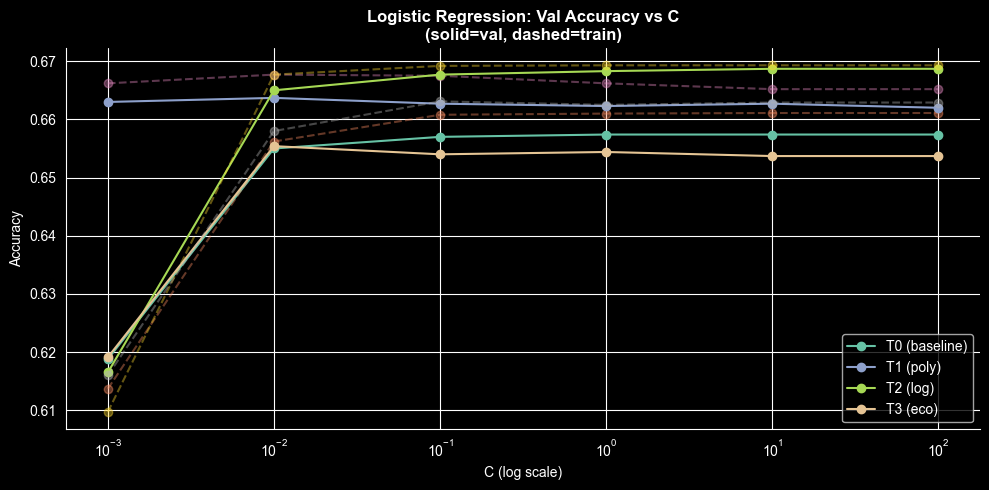

In [102]:
# ── LR: Val accuracy curves by feature space ─────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

for space_name in spaces:
    subset = lr_df[lr_df['Space'] == space_name]
    ax.plot(C_values, subset['Val Acc'].values, marker='o', label=space_name)
    ax.plot(C_values, subset['Train Acc'].values, marker='o',
            linestyle='--', alpha=0.4)

ax.set_xscale('log')
ax.set_xlabel('C (log scale)')
ax.set_ylabel('Accuracy')
ax.set_title('Logistic Regression: Val Accuracy vs C\n(solid=val, dashed=train)',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig("figures/fig_lr_sweep.png", dpi=150, bbox_inches='tight')
plt.show()

In [103]:
# ── KNN sweep: k ─────────────────────────────────────────────────────────────
# Smaller k → more complex model (low bias, high variance / overfitting).
# Larger k → smoother boundaries (high bias, low variance / underfitting).

K_values = [1, 3, 5, 10, 20, 50]
knn_results = []

for space_name, (Xtr, Xv, Xte) in spaces.items():
    for k in K_values:
        model = KNeighborsClassifier(n_neighbors=k)
        scores = score_model(model, Xtr, y_train, Xv, y_val)
        row = {'Model': 'KNN', 'Space': space_name,
               'Hyperparam': f'k={k}', **scores}
        knn_results.append(row)
        all_results.append(row)

knn_df = pd.DataFrame(knn_results)
print("KNN sweep complete.")
knn_df

KNN sweep complete.


,Model,Space,Hyperparam,Train Acc,Val Acc,Precision,Recall,F1
0,KNN,T0 (baseline),k=1,1.0000,0.6185,0.6196,0.6185,0.6188
1,KNN,T0 (baseline),k=3,0.8071,0.6221,0.6240,0.6221,0.6225
2,KNN,T0 (baseline),k=5,0.7600,0.6211,0.6229,0.6211,0.6214
3,KNN,T0 (baseline),k=10,0.7110,0.6281,0.6349,0.6281,0.6293
4,KNN,T0 (baseline),k=20,0.6873,0.6301,0.6355,0.6301,0.6315
5,KNN,T0 (baseline),k=50,0.6623,0.6301,0.6387,0.6301,0.6301
6,KNN,T1 (poly),k=1,1.0000,0.6142,0.6152,0.6142,0.6146
7,KNN,T1 (poly),k=3,0.8063,0.6248,0.6265,0.6248,0.6253
8,KNN,T1 (poly),k=5,0.7642,0.6211,0.6225,0.6211,0.6215
9,KNN,T1 (poly),k=10,0.7123,0.6338,0.6400,0.6338,0.6349


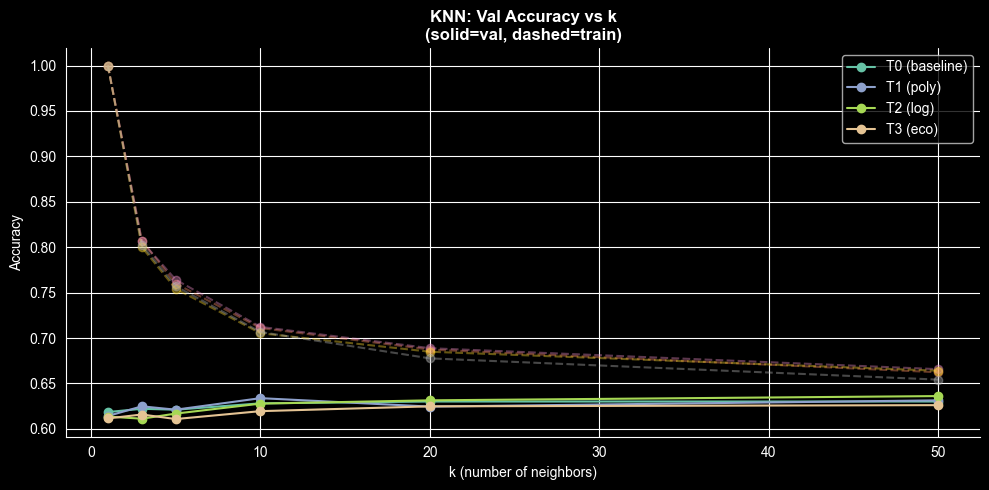

In [104]:
# ── KNN: Val accuracy curves ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

for space_name in spaces:
    subset = knn_df[knn_df['Space'] == space_name]
    ax.plot(K_values, subset['Val Acc'].values, marker='o', label=space_name)
    ax.plot(K_values, subset['Train Acc'].values, marker='o',
            linestyle='--', alpha=0.4)

ax.set_xlabel('k (number of neighbors)')
ax.set_ylabel('Accuracy')
ax.set_title('KNN: Val Accuracy vs k\n(solid=val, dashed=train)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig("figures/fig_knn_sweep.png", dpi=150, bbox_inches='tight')
plt.show()

In [105]:
# ── SVM sweep: C ─────────────────────────────────────────────────────────────
# C controls the margin-violation penalty.
# Small C → wider margin, more misclassifications allowed (higher bias).
# Large C → hard margin, fits training data tightly (higher variance).
# NOTE: SVM on poly space is slow — poly features are pre-computed (explicit), so we skip it and note this in the results.

SVM_C_values = [0.01, 0.1, 1, 10, 100, 1000]
svm_results = []

# Skip poly for SVM (too many features → very slow; use kernel trick instead)
svm_spaces = {k: v for k, v in spaces.items() if k != 'T1 (poly)'}

for space_name, (Xtr, Xv, Xte) in svm_spaces.items():
    for C in SVM_C_values:
        model = SVC(kernel='rbf', C=C,
                    class_weight='balanced',
                    random_state=RANDOM_STATE)
        scores = score_model(model, Xtr, y_train, Xv, y_val)
        row = {'Model': 'SVM', 'Space': space_name,
               'Hyperparam': f'C={C}', **scores}
        svm_results.append(row)
        all_results.append(row)

# For T1 (poly), use SVM with poly kernel instead (equivalent, much faster)
for C in SVM_C_values:
    model = SVC(kernel='poly', degree=2, C=C,
                class_weight='balanced',
                random_state=RANDOM_STATE)
    scores = score_model(model, X_train_scaled, y_train, X_val_scaled, y_val)
    row = {'Model': 'SVM', 'Space': 'T1 (poly)',
           'Hyperparam': f'C={C}', **scores}
    svm_results.append(row)
    all_results.append(row)

svm_df = pd.DataFrame(svm_results)
print("SVM sweep complete.")
svm_df

SVM sweep complete.


,Model,Space,Hyperparam,Train Acc,Val Acc,Precision,Recall,F1
0,SVM,T0 (baseline),C=0.01,0.6223,0.6318,0.6486,0.6318,0.6338
1,SVM,T0 (baseline),C=0.1,0.6648,0.6587,0.6588,0.6587,0.6576
2,SVM,T0 (baseline),C=1,0.6814,0.6693,0.6697,0.6693,0.6690
3,SVM,T0 (baseline),C=10,0.6944,0.6677,0.6676,0.6677,0.6675
4,SVM,T0 (baseline),C=100,0.7165,0.6557,0.6558,0.6557,0.6555
5,SVM,T0 (baseline),C=1000,0.7475,0.6411,0.6418,0.6411,0.6413
6,SVM,T2 (log),C=0.01,0.6184,0.6304,0.6473,0.6304,0.6325
7,SVM,T2 (log),C=0.1,0.6711,0.6663,0.6665,0.6663,0.6658
8,SVM,T2 (log),C=1,0.6855,0.6700,0.6712,0.6700,0.6703
9,SVM,T2 (log),C=10,0.6983,0.6683,0.6686,0.6683,0.6682


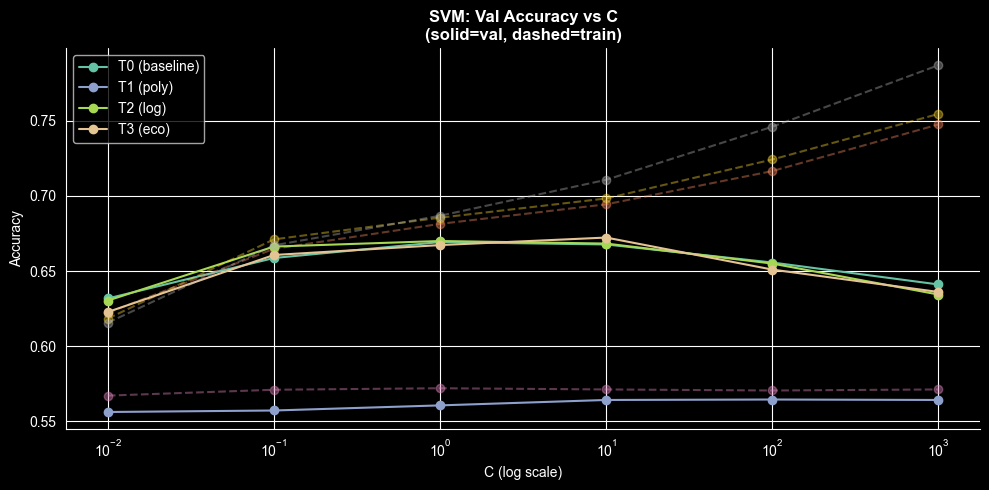

In [106]:
# ── SVM: Val accuracy curves ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

for space_name in spaces:
    subset = svm_df[svm_df['Space'] == space_name]
    ax.plot(SVM_C_values, subset['Val Acc'].values, marker='o', label=space_name)
    ax.plot(SVM_C_values, subset['Train Acc'].values, marker='o',
            linestyle='--', alpha=0.4)

ax.set_xscale('log')
ax.set_xlabel('C (log scale)')
ax.set_ylabel('Accuracy')
ax.set_title('SVM: Val Accuracy vs C\n(solid=val, dashed=train)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig("figures/fig_svm_sweep.png", dpi=150, bbox_inches='tight')
plt.show()

---
# Neural Network (MLP)

We use sklearn's `MLPClassifier` (Multi-Layer Perceptron).
The "regularization" sweep varies the hidden layer architecture,
which controls model capacity (analogous to complexity vs. regularization).
We also apply `alpha` (L2 weight decay) to regularize.
Trained on all 4 feature spaces, 6 configurations each.

In [107]:
# ── MLP configurations (6 settings) ─────────────────────────────────────────
# We vary hidden layer size and alpha (L2 penalty) together.
# Small networks + high alpha → high bias (underfitting)
# Large networks + low alpha → high variance (overfitting)

mlp_configs = [
    {'hidden_layer_sizes': (32,),       'alpha': 1.0},
    {'hidden_layer_sizes': (64,),       'alpha': 0.1},
    {'hidden_layer_sizes': (128,),      'alpha': 0.01},
    {'hidden_layer_sizes': (64, 32),    'alpha': 0.1},
    {'hidden_layer_sizes': (128, 64),   'alpha': 0.01},
    {'hidden_layer_sizes': (128, 64, 32), 'alpha': 0.001},
]

mlp_results = []

for space_name, (Xtr, Xv, Xte) in spaces.items():
    for cfg in mlp_configs:
        model = MLPClassifier(
            hidden_layer_sizes=cfg['hidden_layer_sizes'],
            alpha=cfg['alpha'],
            max_iter=500,
            random_state=RANDOM_STATE,
            early_stopping=True,
            validation_fraction=0.1,
        )
        scores = score_model(model, Xtr, y_train, Xv, y_val)
        label = f"layers={cfg['hidden_layer_sizes']}, α={cfg['alpha']}"
        row = {'Model': 'MLP', 'Space': space_name,
               'Hyperparam': label, **scores}
        mlp_results.append(row)
        all_results.append(row)

mlp_df = pd.DataFrame(mlp_results)
print("MLP sweep complete.")
mlp_df

MLP sweep complete.


,Model,Space,Hyperparam,Train Acc,Val Acc,Precision,Recall,F1
0,MLP,T0 (baseline),"layers=(32,), α=1.0",0.6739,0.6683,0.6695,0.6683,0.6663
1,MLP,T0 (baseline),"layers=(64,), α=0.1",0.6720,0.6697,0.6738,0.6697,0.6700
2,MLP,T0 (baseline),"layers=(128,), α=0.01",0.6722,0.6617,0.6627,0.6617,0.6621
3,MLP,T0 (baseline),"layers=(64, 32), α=0.1",0.6771,0.6687,0.6703,0.6687,0.6692
4,MLP,T0 (baseline),"layers=(128, 64), α=0.01",0.6808,0.6670,0.6684,0.6670,0.6645
5,MLP,T0 (baseline),"layers=(128, 64, 32), α=0.001",0.6803,0.6697,0.6726,0.6697,0.6658
6,MLP,T1 (poly),"layers=(32,), α=1.0",0.6795,0.6687,0.6689,0.6687,0.6686
7,MLP,T1 (poly),"layers=(64,), α=0.1",0.6828,0.6650,0.6654,0.6650,0.6638
8,MLP,T1 (poly),"layers=(128,), α=0.01",0.6850,0.6720,0.6721,0.6720,0.6715
9,MLP,T1 (poly),"layers=(64, 32), α=0.1",0.6798,0.6520,0.6558,0.6520,0.6529


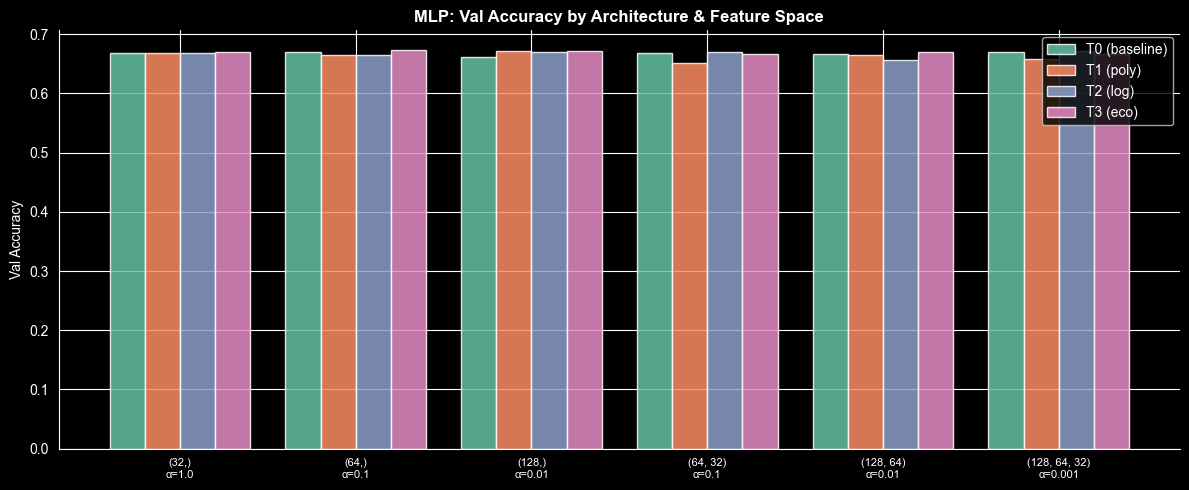

In [108]:
# ── MLP: Val accuracy by architecture per feature space ───────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

config_labels = [f"{c['hidden_layer_sizes']}\nα={c['alpha']}" for c in mlp_configs]
x = np.arange(len(mlp_configs))
width = 0.2
offsets = [-1.5, -0.5, 0.5, 1.5]

for i, space_name in enumerate(spaces):
    subset = mlp_df[mlp_df['Space'] == space_name]
    ax.bar(x + offsets[i] * width, subset['Val Acc'].values,
           width, label=space_name, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(config_labels, fontsize=8)
ax.set_ylabel('Val Accuracy')
ax.set_title('MLP: Val Accuracy by Architecture & Feature Space', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig("figures/fig_mlp_sweep.png", dpi=150, bbox_inches='tight')
plt.show()

---
# Full Results Table & Final Analysis

In [109]:
# ── Complete results table (all 72+ models) ───────────────────────────────────
full_results_df = pd.DataFrame(all_results)
full_results_df = full_results_df.sort_values(['Model', 'Space', 'Val Acc'], ascending=[True, True, False])
full_results_df = full_results_df.reset_index(drop=True)

print(f"Total models trained: {len(full_results_df)}")
full_results_df

Total models trained: 96


,Model,Space,Hyperparam,Train Acc,Val Acc,Precision,Recall,F1
0,KNN,T0 (baseline),k=20,0.6873,0.6301,0.6355,0.6301,0.6315
1,KNN,T0 (baseline),k=50,0.6623,0.6301,0.6387,0.6301,0.6301
2,KNN,T0 (baseline),k=10,0.7110,0.6281,0.6349,0.6281,0.6293
3,KNN,T0 (baseline),k=3,0.8071,0.6221,0.6240,0.6221,0.6225
4,KNN,T0 (baseline),k=5,0.7600,0.6211,0.6229,0.6211,0.6214
...,...,...,...,...,...,...,...,...
91,SVM,T3 (eco),C=1,0.6868,0.6673,0.6673,0.6673,0.6671
92,SVM,T3 (eco),C=0.1,0.6671,0.6607,0.6609,0.6607,0.6596
93,SVM,T3 (eco),C=100,0.7460,0.6510,0.6517,0.6510,0.6513
94,SVM,T3 (eco),C=1000,0.7869,0.6361,0.6381,0.6361,0.6368


In [110]:
# ── Best configuration per model ──────────────────────────────────────────────
best_per_model = full_results_df.loc[
    full_results_df.groupby('Model')['Val Acc'].idxmax()
].reset_index(drop=True)

print('=== Best Configuration Per Model ===')
best_per_model[['Model', 'Space', 'Hyperparam',
                'Train Acc', 'Val Acc', 'Precision', 'Recall', 'F1']]

=== Best Configuration Per Model ===


,Model,Space,Hyperparam,Train Acc,Val Acc,Precision,Recall,F1
0,KNN,T2 (log),k=50,0.6640,0.6361,0.6448,0.6361,0.6357
1,Logistic Regression,T2 (log),C=10,0.6693,0.6687,0.6704,0.6687,0.6691
2,MLP,T3 (eco),"layers=(64,), α=0.1",0.6760,0.6726,0.6730,0.6726,0.6720
3,SVM,T3 (eco),C=10,0.7107,0.6723,0.6725,0.6723,0.6723


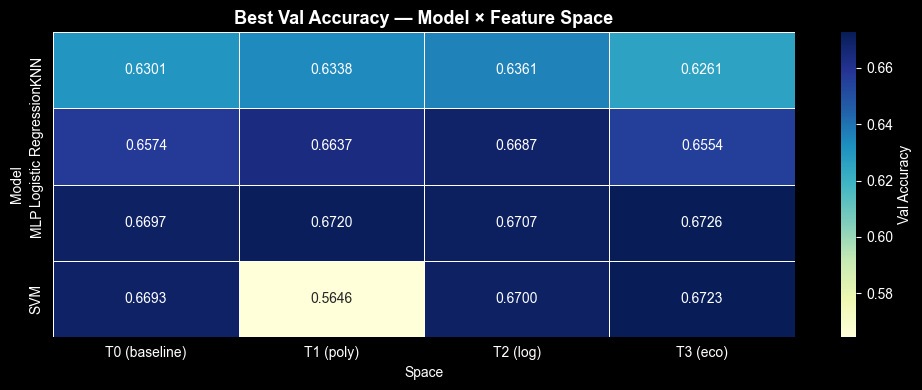

In [111]:
# ── Val accuracy by model × feature space (heatmap) ───────────────────────────
# Best val acc for each (model, space) pair
heatmap_data = (
    full_results_df.groupby(['Model', 'Space'])['Val Acc']
    .max()
    .unstack('Space')
)

plt.figure(figsize=(10, 4))
sns.heatmap(heatmap_data, annot=True, fmt='.4f', cmap='YlGnBu',
            linewidths=0.5, cbar_kws={'label': 'Val Accuracy'})
plt.title('Best Val Accuracy — Model × Feature Space', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("figures/fig_heatmap_results.png", dpi=150, bbox_inches='tight')
plt.show()

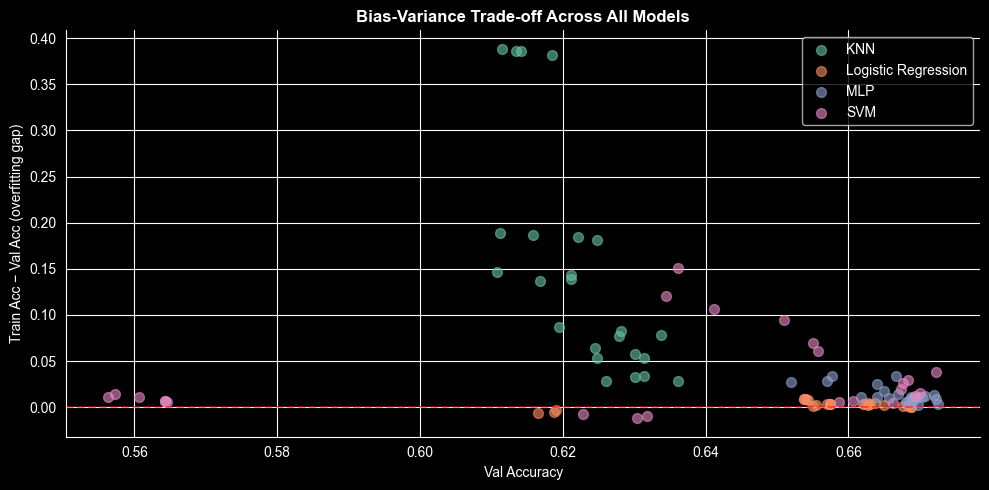

In [112]:
# ── Bias-Variance gap per model ───────────────────────────────────────────────
full_results_df['Gap (Train-Val)'] = (full_results_df['Train Acc']
                                      - full_results_df['Val Acc']).round(4)

fig, ax = plt.subplots(figsize=(10, 5))
for model_name, group in full_results_df.groupby('Model'):
    ax.scatter(group['Val Acc'], group['Gap (Train-Val)'],
               label=model_name, alpha=0.6, s=50)

ax.axhline(0, color='red', linestyle='--', alpha=0.5)
ax.set_xlabel('Val Accuracy')
ax.set_ylabel('Train Acc − Val Acc (overfitting gap)')
ax.set_title('Bias-Variance Trade-off Across All Models', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig("figures/fig_bias_variance.png", dpi=150, bbox_inches='tight')
plt.show()

In [113]:
# ── Final evaluation on TEST SET (best model only) ────────────────────────────
# We use the test set exactly once here, at the very end.

print('=== FINAL TEST SET EVALUATION ===')
print('Using best configuration from each model family.\n')

# Identify best overall config per model
space_map = {
    'T0 (baseline)': (X_train_scaled, X_val_scaled, X_test_scaled),
    'T1 (poly)': (X_train_poly, X_val_poly, X_test_poly),
    'T2 (log)': (X_train_log, X_val_log, X_test_log),
    'T3 (eco)': (X_train_eco, X_val_eco, X_test_eco),
}

test_results = []

for _, row in best_per_model.iterrows():
    Xtr, Xv, Xte = space_map[row['Space']]

    if row['Model'] == 'Logistic Regression':
        C_val = float(row['Hyperparam'].split('=')[1])
        model = LogisticRegression(C=C_val, max_iter=1000,
                                   class_weight='balanced',
                                   random_state=RANDOM_STATE)
    elif row['Model'] == 'KNN':
        k_val = int(row['Hyperparam'].split('=')[1])
        model = KNeighborsClassifier(n_neighbors=k_val)
    elif row['Model'] == 'SVM':
        C_val = float(row['Hyperparam'].split('=')[1])
        kernel = 'poly' if row['Space'] == 'T1 (poly)' else 'rbf'
        model = SVC(kernel=kernel, C=C_val,
                    class_weight='balanced',
                    random_state=RANDOM_STATE)
    elif row['Model'] == 'MLP':
        # Parse layers and alpha from label string
        best_cfg = mlp_configs[
            mlp_df[mlp_df['Space'] == row['Space']]['Val Acc'].idxmax()
            % len(mlp_configs)
            ]
        model = MLPClassifier(
            hidden_layer_sizes=best_cfg['hidden_layer_sizes'],
            alpha=best_cfg['alpha'],
            max_iter=500,
            random_state=RANDOM_STATE,
        )

    # Fit on train+val combined, evaluate on test
    X_trainval = np.vstack([Xtr, Xv])
    y_trainval = np.concatenate([y_train, y_val])
    model.fit(X_trainval, y_trainval)

    y_test_pred = model.predict(Xte)
    test_acc = accuracy_score(y_test, y_test_pred)
    test_f1 = f1_score(y_test, y_test_pred, average='weighted', zero_division=0)
    test_prec = precision_score(y_test, y_test_pred, average='weighted', zero_division=0)
    test_rec = recall_score(y_test, y_test_pred, average='weighted', zero_division=0)

    print(f"── {row['Model']} ({row['Space']}, {row['Hyperparam']})")
    print(f"   Test Accuracy : {test_acc:.4f}")
    print(f"   Test F1       : {test_f1:.4f}")
    print()
    print(classification_report(y_test, y_test_pred, target_names=le_target.classes_))

    test_results.append({
        'Model': row['Model'],
        'Space': row['Space'],
        'Test Acc': round(test_acc, 4),
        'Test F1': round(test_f1, 4),
        'Precision': round(test_prec, 4),
        'Recall': round(test_rec, 4),
    })

test_results_df = pd.DataFrame(test_results)
test_results_df

=== FINAL TEST SET EVALUATION ===
Using best configuration from each model family.

── KNN (T2 (log), k=50)
   Test Accuracy : 0.6125
   Test F1       : 0.6117

              precision    recall  f1-score   support

       black       0.59      0.58      0.59      1366
        draw       1.00      0.42      0.59       143
       white       0.61      0.66      0.64      1500

    accuracy                           0.61      3009
   macro avg       0.74      0.55      0.60      3009
weighted avg       0.62      0.61      0.61      3009

── Logistic Regression (T2 (log), C=10)
   Test Accuracy : 0.6544
   Test F1       : 0.6551

              precision    recall  f1-score   support

       black       0.61      0.65      0.63      1366
        draw       0.99      0.93      0.96       143
       white       0.67      0.63      0.65      1500

    accuracy                           0.65      3009
   macro avg       0.76      0.74      0.75      3009
weighted avg       0.66      0.65      

,Model,Space,Test Acc,Test F1,Precision,Recall
0,KNN,T2 (log),0.6125,0.6117,0.6230,0.6125
1,Logistic Regression,T2 (log),0.6544,0.6551,0.6569,0.6544
2,MLP,T3 (eco),0.6481,0.6483,0.6489,0.6481
3,SVM,T3 (eco),0.6577,0.6576,0.6578,0.6577


Best overall: SVM on T3 (eco)


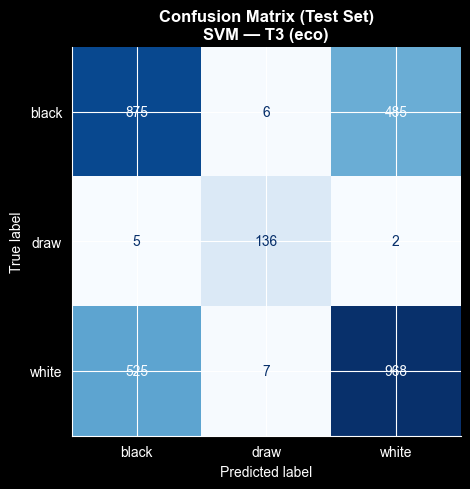

In [114]:
# ── Confusion matrix for best overall model on test set ───────────────────────
best_overall_idx = test_results_df['Test Acc'].idxmax()
best_overall = test_results_df.loc[best_overall_idx]
print(f"Best overall: {best_overall['Model']} on {best_overall['Space']}")

# Re-fit best model for confusion matrix (reuse last loop's model if it matches)
# Quick re-identification
best_row = best_per_model.loc[
    best_per_model['Model'] == best_overall['Model']
    ].iloc[0]

Xtr, Xv, Xte = space_map[best_overall['Space']]
X_trainval = np.vstack([Xtr, Xv])
y_trainval = np.concatenate([y_train, y_val])
model.fit(X_trainval, y_trainval)  # model still holds the best config from loop above

y_test_pred_best = model.predict(Xte)
cm = confusion_matrix(y_test, y_test_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_target.classes_)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f"Confusion Matrix (Test Set)\n{best_overall['Model']} — {best_overall['Space']}",
             fontweight='bold')
plt.tight_layout()
plt.savefig("figures/fig_final_confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()